# Geração dos índices NVDI e NDWI

#### Importação das bibliotecas

In [ ]:
import cv2
import numpy as np
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
from PIL import Image

##### O **NDVI** é utilizado para avaliar a densidade e a saúde da vegetação:

##### $$NDVI = \frac{NIR - RED}{NIR + RED}$$

##### O **NDWI** (Normalized Difference Water Index) é útil para monitorar o estresse hídrico na vegetação bem como áreas com presença de água:

##### $$NDWI = \frac{GREEN - NIR}{GREEN + NIR}$$

#### É importante observar que ambos os indíces apresentaram valores no range [-1, 1] onde para o NVDI valores maiores que 0 indicam presença de plantas (alta reflexão no NIR) e valores menores que 0 indicam a ausência. Considerando o NDWI, valores maiores que 0 indicam presença água (alta absorção no NIR), enquanto valores menores que 0 geralmente representam solo ou vegetação.

#### Foi então criada a função *calculate_and_save_nvdi* que faz a leitura dos quatro canais das imagens, calcula o NVDI e depois converte os valores pro range [0, 255] para a conversão em imagem jpg.

In [ ]:
def calculate_and_save_ndvi(base_path):
    nir_dir = os.path.join(base_path, "images", "nir")
    rgb_dir = os.path.join(base_path, "images", "rgb")
    output_dir = os.path.join(base_path, "images", "nvdi")

    os.makedirs(output_dir, exist_ok=True)

    #Lista as imagens 
    images = [f for f in os.listdir(nir_dir) if f.lower().endswith(('.jpg', '.png', '.tif'))]

    print(f"Processando {len(images)} imagens em: {base_path}")

    for filename in tqdm(images):
        nir_path = os.path.join(nir_dir, filename)
        rgb_path = os.path.join(rgb_dir, filename.replace('.png', '.jpg'))

        #Carrega as imagens
        #NIR geralmente é single channel e RGB são 3 canais
        nir = cv2.imread(nir_path, cv2.IMREAD_GRAYSCALE).astype(float)
        rgb = cv2.imread(rgb_path).astype(float)

        if nir is None or rgb is None:
            continue

        #No OpenCV, o padrão é BGR, então o Vermelho (Red) é o índice 2
        red = rgb[:, :, 2]

        #Cálculo do NDVI
        denominator = (nir + red)
        denominator[denominator == 0] = 1e-10 #Pequeno offset para evitar divisão por zero
        
        ndvi = (nir - red) / denominator

        #Mapeia de [-1, 1] para [0, 255]
        ndvi_visual = ((ndvi + 1) / 2 * 255).astype(np.uint8)
        
        cv2.imwrite(os.path.join(output_dir, filename), ndvi_visual)

# Execução para as pastas train, val e test
root_dir = r"C:\Users\lfern\Downloads\Agriculture-Vision-2021\Agriculture-Vision-2021"
for split in ["train", "val", "test"]:
    split_path = os.path.join(root_dir, split)
    if os.path.exists(split_path):
        calculate_and_save_ndvi(split_path)

Processando 56944 imagens em: C:\Users\lfern\Downloads\Agriculture-Vision-2021\Agriculture-Vision-2021\train


100%|██████████| 56944/56944 [22:57<00:00, 41.35it/s] 


Processando 18334 imagens em: C:\Users\lfern\Downloads\Agriculture-Vision-2021\Agriculture-Vision-2021\val


100%|██████████| 18334/18334 [06:23<00:00, 47.81it/s]


Processando 19708 imagens em: C:\Users\lfern\Downloads\Agriculture-Vision-2021\Agriculture-Vision-2021\test


100%|██████████| 19708/19708 [08:17<00:00, 39.59it/s] 


#### Por último foi realizado o cálculo do NDWI através da função *calculate_and_save_ndwi* e os indíces foram salvos no formato jpg.

In [ ]:
def calculate_and_save_ndwi(base_path):
    nir_dir = os.path.join(base_path, "images", "nir")
    rgb_dir = os.path.join(base_path, "images", "rgb")
    output_dir = os.path.join(base_path, "images", "ndwi")

    os.makedirs(output_dir, exist_ok=True)

    #Lista as imagens
    images = [f for f in os.listdir(nir_dir) if f.lower().endswith(('.jpg', '.png', '.tif'))]

    print(f"Processando {len(images)} imagens em: {base_path}")

    for filename in tqdm(images):
        nir_path = os.path.join(nir_dir, filename)
        rgb_path = os.path.join(rgb_dir, filename.replace('.png', '.jpg')) # Ajuste a extensão se necessário

        #Carrega as imagens
        #NIR geralmente é single channel e RGB são 3 canais
        nir = cv2.imread(nir_path, cv2.IMREAD_GRAYSCALE).astype(float)
        rgb = cv2.imread(rgb_path).astype(float)

        if nir is None or rgb is None:
            continue

        #No OpenCV, o padrão é BGR, então o Verde (Green) é o índice 1
        green = rgb[:, :, 1]

        #Cálculo do NDWI 
        denominator = (green +nir)
        denominator[denominator == 0] = 1e-10 #Pequeno offset para evitar divisão por zero
        
        ndwi = (green - nir) / denominator

        #Mapeia de [-1, 1] para [0, 255]
        ndwi_visual = ((ndwi + 1) / 2 * 255).astype(np.uint8)
        
        cv2.imwrite(os.path.join(output_dir, filename), ndwi_visual)

#Execução para as pastas train, val e test
root_dir = r"C:\Users\lfern\Downloads\Agriculture-Vision-2021\Agriculture-Vision-2021"
for split in ["train", "val", "test"]:
    split_path = os.path.join(root_dir, split)
    if os.path.exists(split_path):
        calculate_and_save_ndwi(split_path)

Processando 56944 imagens em: C:\Users\lfern\Downloads\Agriculture-Vision-2021\Agriculture-Vision-2021\train


100%|██████████| 56944/56944 [17:11<00:00, 55.22it/s]


Processando 18334 imagens em: C:\Users\lfern\Downloads\Agriculture-Vision-2021\Agriculture-Vision-2021\val


100%|██████████| 18334/18334 [05:40<00:00, 53.88it/s] 


Processando 19708 imagens em: C:\Users\lfern\Downloads\Agriculture-Vision-2021\Agriculture-Vision-2021\test


100%|██████████| 19708/19708 [06:11<00:00, 53.09it/s] 


### Visualização das imagens geradas

#### Primeiro será observada uma figura com o label "double planta" que sinaliza que há sobreposição de dois tipos de planta no mesmo local da fazenda, portanto, é esperado alta densidade de vegetação o que será sinalizado pelo NVDI com altos valores.

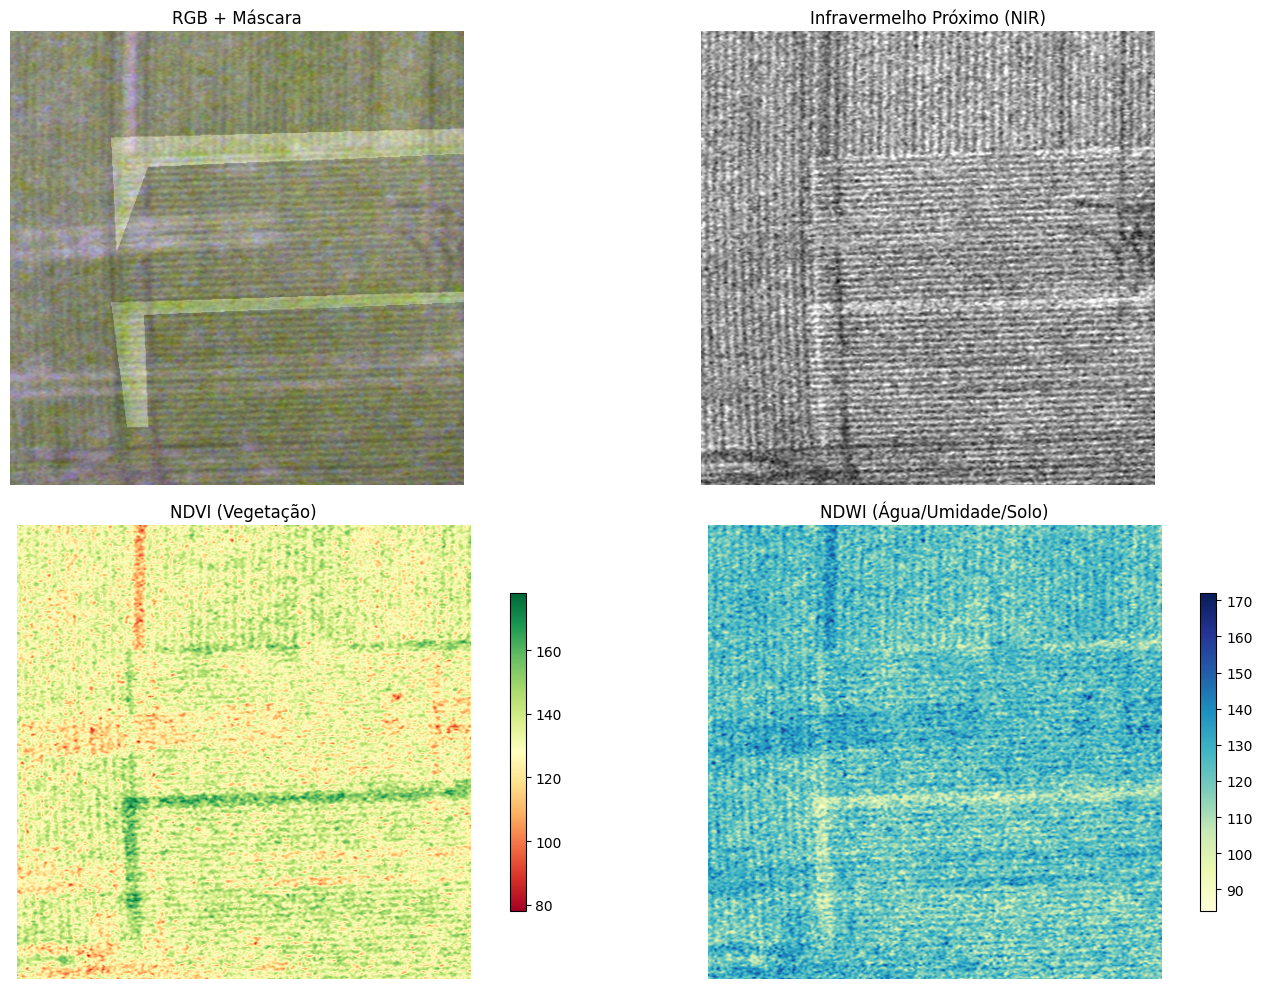

In [45]:
name = "4C43HGMPK_796-4109-1308-4621.jpg"
dir_rgb = r"C:\Users\lfern\Downloads\Agriculture-Vision-2021\Agriculture-Vision-2021\val\images\rgb/" + name
dir_nir = r"C:\Users\lfern\Downloads\Agriculture-Vision-2021\Agriculture-Vision-2021\val\images\nir/" + name
dir_nvdi = r"C:\Users\lfern\Downloads\Agriculture-Vision-2021\Agriculture-Vision-2021\val\images\nvdi/" + name
dir_ndwi = r"C:\Users\lfern\Downloads\Agriculture-Vision-2021\Agriculture-Vision-2021\val\images\ndwi/" + name

labels = ["endrow", "double_plant", "water", "waterway", "drydown", "nutrient_deficiency", "planter_skip", "weed_cluster", "storm_damage"]

dir_label = []
for label in labels:
    dir_label.append(r"C:\Users\lfern\Downloads\Agriculture-Vision-2021\Agriculture-Vision-2021\val\labels/" + label + "/" + name.replace(".jpg", ".png"))

img_rgb = Image.open(dir_rgb)
img_nir = Image.open(dir_nir)
img_nvdi = Image.open(dir_nvdi)
img_ndwi = Image.open(dir_ndwi)

mask = Image.open(dir_label[1]).convert('L')
mask_np = np.array(mask)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

#1. RGB + Máscara (Linha 0, Coluna 0)
axes[0, 0].imshow(img_rgb)
axes[0, 0].imshow(mask_np, cmap='gray', alpha=0.2) #Máscara
axes[0, 0].set_title("RGB + Máscara", fontsize=12)
axes[0, 0].axis('off')

#2. Imagem NIR (Linha 0, Coluna 1)
axes[0, 1].imshow(img_nir, cmap='gray')
axes[0, 1].set_title("Infravermelho Próximo (NIR)", fontsize=12)
axes[0, 1].axis('off')

#3. Índice NDVI (Linha 1, Coluna 0)
# Dica: Usar colormaps como 'RdYlGn' (Red-Yellow-Green) ajuda muito a ver a vegetação
im_ndvi = axes[1, 0].imshow(img_nvdi, cmap='RdYlGn')
axes[1, 0].set_title("NDVI (Vegetação)", fontsize=12)
axes[1, 0].axis('off')
fig.colorbar(im_ndvi, ax=axes[1, 0], shrink=0.7) # Barra de intensidade

# 4. Índice NDWI (Linha 1, Coluna 1)
# Dica: Usar colormaps como 'Blues' ou 'YlGnBu' ajuda a destacar a água
im_ndwi = axes[1, 1].imshow(img_ndwi, cmap='YlGnBu')
axes[1, 1].set_title("NDWI (Água/Umidade/Solo)", fontsize=12)
axes[1, 1].axis('off')
fig.colorbar(im_ndwi, ax=axes[1, 1], shrink=0.7)

plt.tight_layout()
plt.show()

#### Depois é selecionada uma imagem com a presença de água e vegetação para ver o comportamento dos índices NVDI e NDWI, onde é notório que o NVDI destacou as áreas com presença de plantas e o NDWI destacou as áreas hídricas.

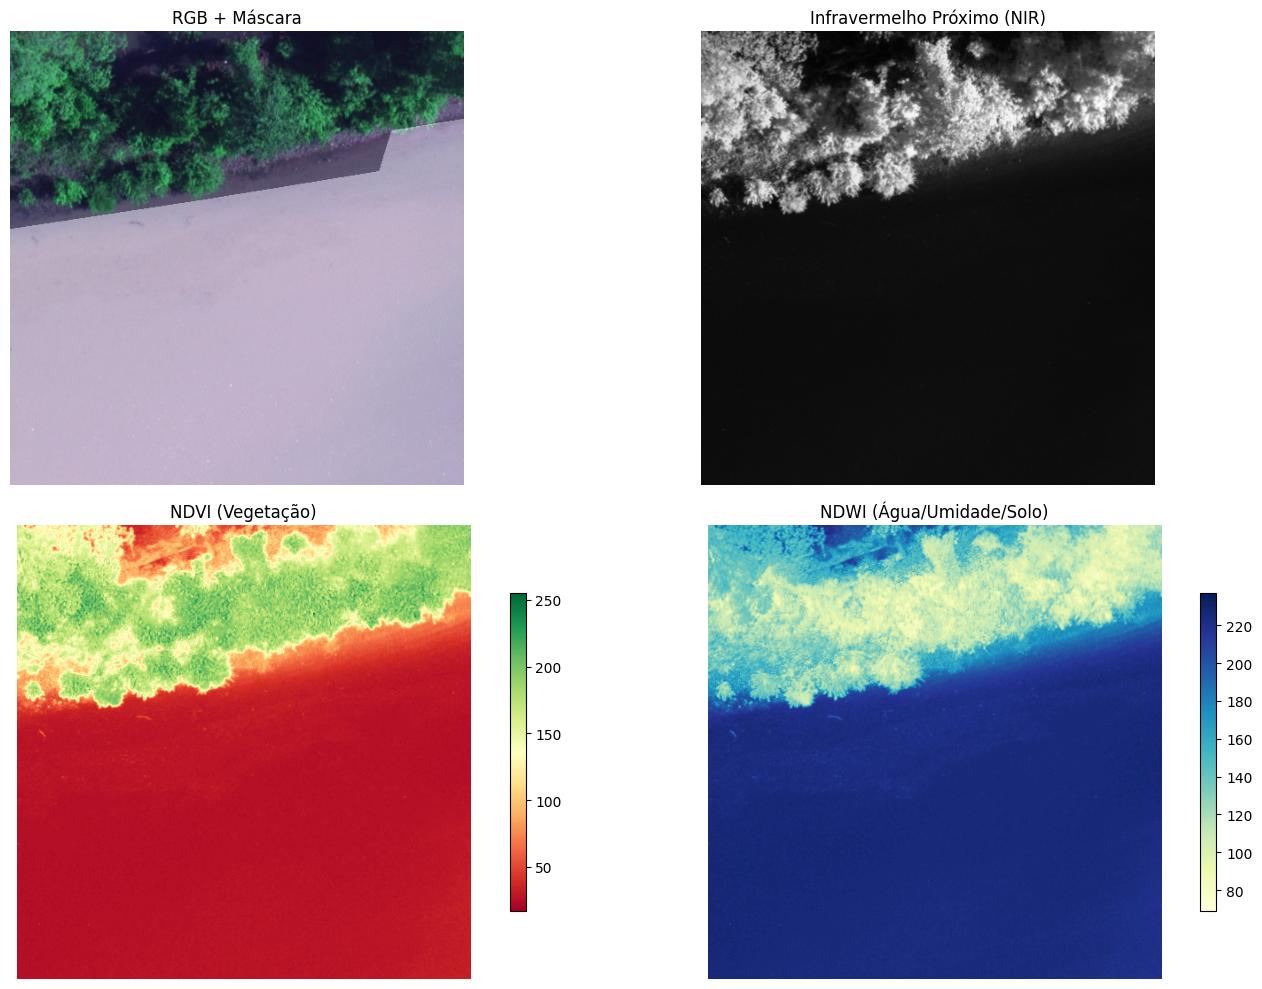

In [42]:
name = "18LX92KA3_4624-20026-5136-20538.jpg"
dir_rgb = r"C:\Users\lfern\Downloads\Agriculture-Vision-2021\Agriculture-Vision-2021\val\images\rgb/" + name
dir_nir = r"C:\Users\lfern\Downloads\Agriculture-Vision-2021\Agriculture-Vision-2021\val\images\nir/" + name
dir_nvdi = r"C:\Users\lfern\Downloads\Agriculture-Vision-2021\Agriculture-Vision-2021\val\images\nvdi/" + name
dir_ndwi = r"C:\Users\lfern\Downloads\Agriculture-Vision-2021\Agriculture-Vision-2021\val\images\ndwi/" + name

labels = ["endrow", "double_plant", "water", "waterway", "drydown", "nutrient_deficiency", "planter_skip", "weed_cluster", "storm_damage"]

dir_label = []
for label in labels:
    dir_label.append(r"C:\Users\lfern\Downloads\Agriculture-Vision-2021\Agriculture-Vision-2021\val\labels/" + label + "/" + name.replace(".jpg", ".png"))

img_rgb = Image.open(dir_rgb)
img_nir = Image.open(dir_nir)
img_nvdi = Image.open(dir_nvdi)
img_ndwi = Image.open(dir_ndwi)

mask = Image.open(dir_label[2]).convert('L') #'L' para escala de cinza/binária
mask_np = np.array(mask)


fig, axes = plt.subplots(2, 2, figsize=(15, 10))

#1. RGB + Máscara (Linha 0, Coluna 0)
axes[0, 0].imshow(img_rgb)
axes[0, 0].imshow(mask_np, cmap='gray', alpha=0.3) #Máscara
axes[0, 0].set_title("RGB + Máscara", fontsize=12)
axes[0, 0].axis('off')

#2. Imagem NIR (Linha 0, Coluna 1)
axes[0, 1].imshow(img_nir, cmap='gray')
axes[0, 1].set_title("Infravermelho Próximo (NIR)", fontsize=12)
axes[0, 1].axis('off')

#3. Índice NDVI (Linha 1, Coluna 0)
# Dica: Usar colormaps como 'RdYlGn' (Red-Yellow-Green) ajuda muito a ver a vegetação
im_ndvi = axes[1, 0].imshow(img_nvdi, cmap='RdYlGn')
axes[1, 0].set_title("NDVI (Vegetação)", fontsize=12)
axes[1, 0].axis('off')
fig.colorbar(im_ndvi, ax=axes[1, 0], shrink=0.7) # Barra de intensidade

# 4. Índice NDWI (Linha 1, Coluna 1)
# Dica: Usar colormaps como 'Blues' ou 'YlGnBu' ajuda a destacar a água
im_ndwi = axes[1, 1].imshow(img_ndwi, cmap='YlGnBu')
axes[1, 1].set_title("NDWI (Água/Umidade/Solo)", fontsize=12)
axes[1, 1].axis('off')
fig.colorbar(im_ndwi, ax=axes[1, 1], shrink=0.7)

plt.tight_layout()
plt.show()